In [1]:
%load_ext autoreload
%autoreload 2

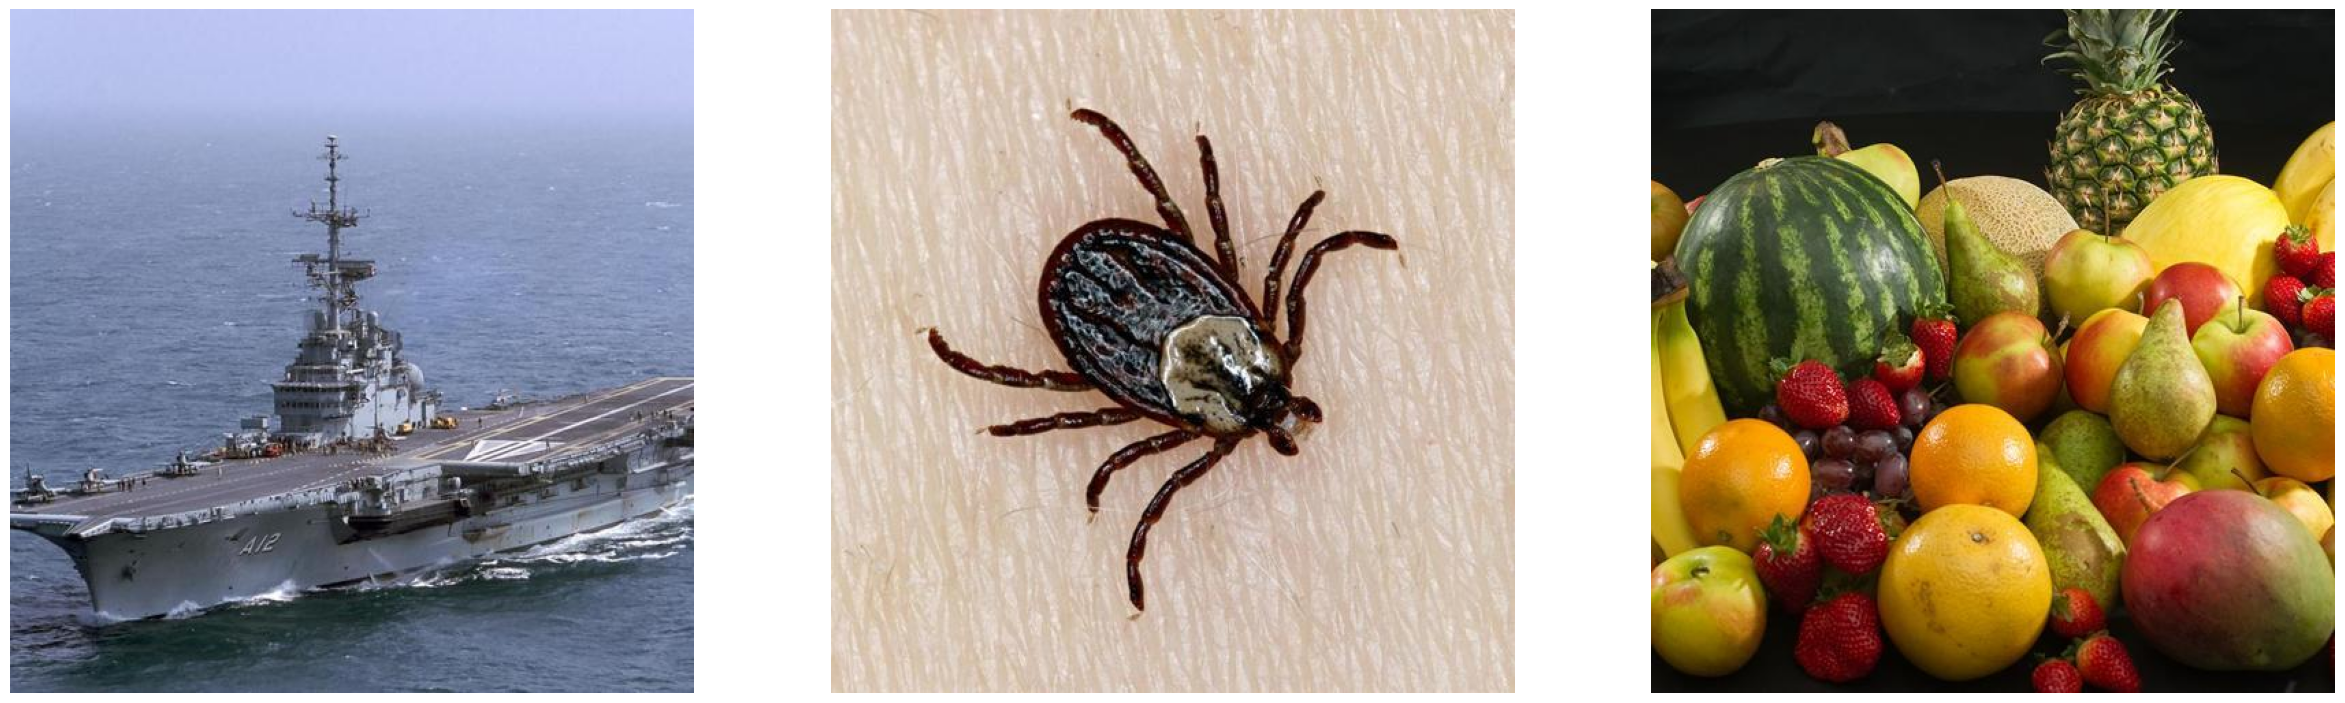

torch.Size([3, 3, 500, 500])


In [2]:
from pathlib import Path
from brain_image.data import batch_load_images
from brain_image.utils import show_image

img = batch_load_images([
    Path("data/things-eeg2/imgs/test_images/00001_aircraft_carrier/aircraft_carrier_06s.jpg"),
    Path("data/things-eeg2/imgs/test_images/00183_tick/tick_06s.jpg"),
    Path("data/things-eeg2/imgs/test_images/00081_fruit/fruit_01b.jpg")
])
show_image(img / 255.)
print(img.shape)

In [3]:
import torch
from brain_image.model.img_encoder import load_image_encoder
device = "cuda"
img_enc = load_image_encoder("clip_vith14", compile=False)
img_enc = img_enc.to(device)

img_emb = img_enc(img.to(device))
img_emb = torch.nn.functional.normalize(img_emb)
img_emb.shape


torch.Size([3, 1024])

In [4]:
from brain_image.reconstruction import IPAdapterReconstructionPipeline


recon = IPAdapterReconstructionPipeline.load_pretrained()
recon

Keyword arguments {'device': device(type='cuda')} are not expected by StableDiffusionXLPipeline and will be ignored.


Loading pipeline components...:   0%|          | 0/7 [00:00<?, ?it/s]

tensor(0.4276, device='cuda:0') tensor(0.2400, device='cuda:0') tensor(0., device='cuda:0') tensor(1., device='cuda:0')


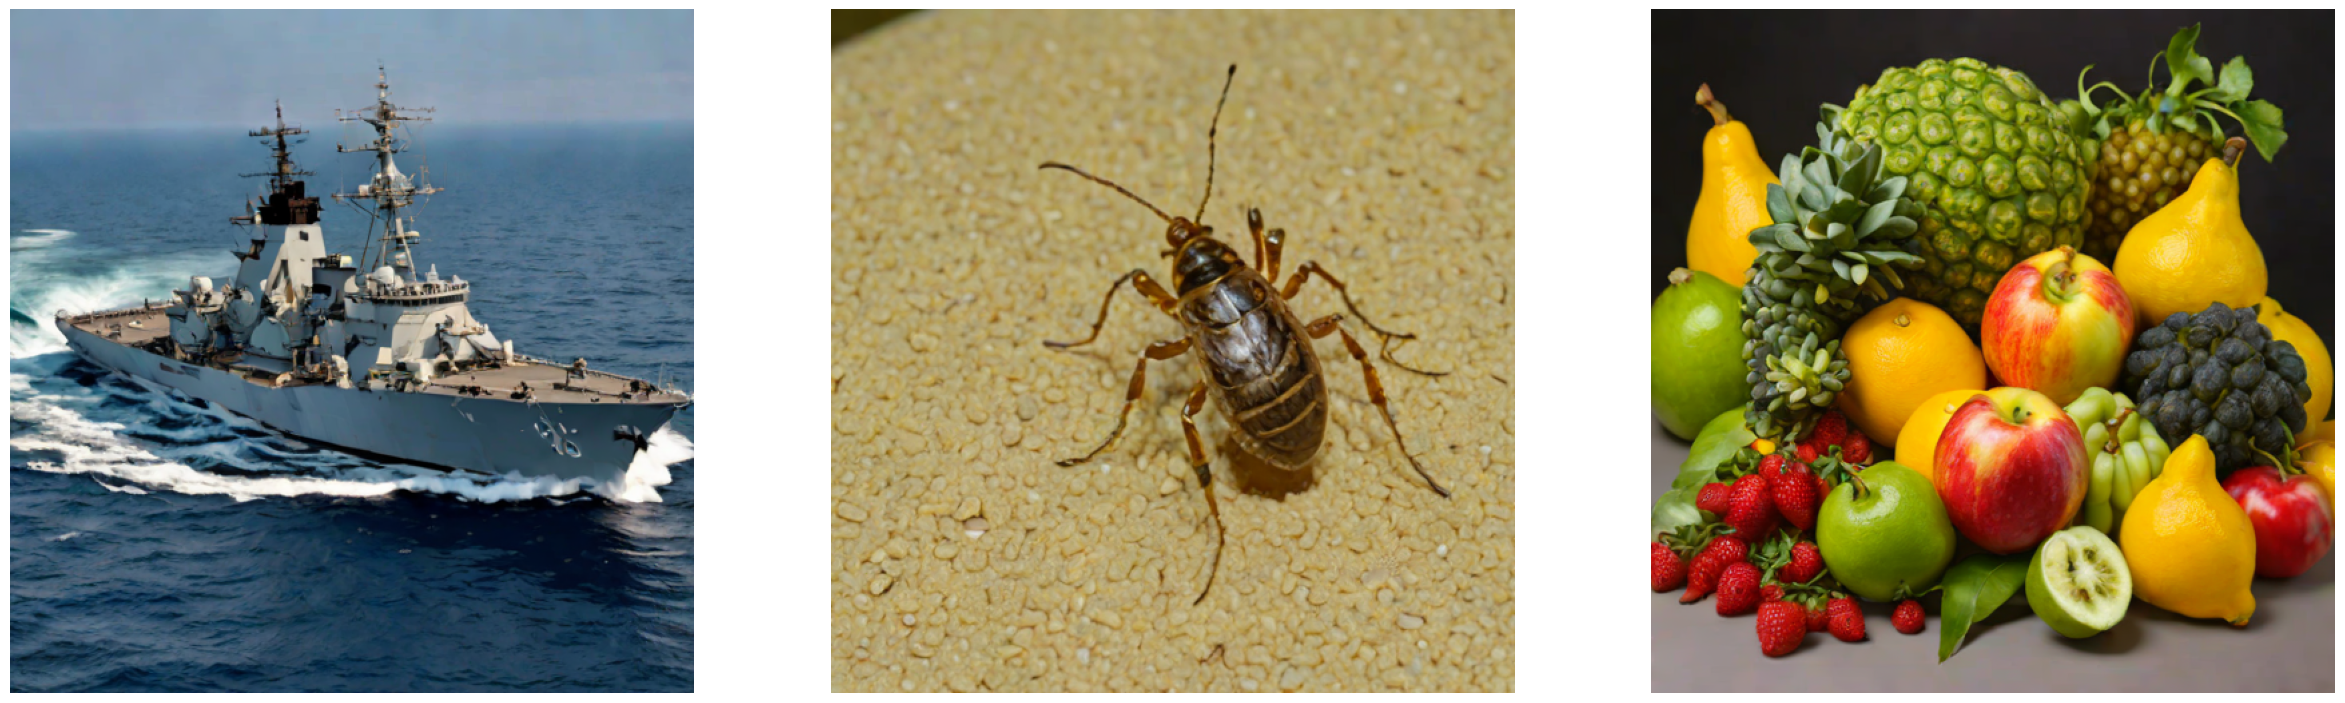

In [5]:
out = recon.reconstruct_latents(img_emb)
print(out.mean(), out.std(), out.min(), out.max())
show_image(out)